# Simplified Implementation of V3 Methodology
In this notebook we'll implement the V3 Methodology developped after our call with M. Weibel. Generally speaking it combined V1 and V2 into a single unified methodology. Concretely this means:
- One set of features is the time-decayed average count of articles, separated into topics
- Second set of features is the time-decayed average embedding, followed by PCA dimension reduction.

A few limitation of this implementation:
- We'll only use the german_news_v1 dataset obtained in `/data`, because we haven't implemented any translation or finer preprocessing
- We'll use the `energy-charts.info` API, which can only return auction price, not spot price yet. This is because we haven't yet downloaded the entire relevant dataset yet.
- We will not run any hyperparameter-tuning in this notebook yet.

We'll make sure to code this notebook somewhat modular so that swapping out these features for the final notebook is easier.

---
## Importing Required Libraries
This section imports all necessary libraries for running the analysis in this notebook

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm import tqdm

# API libraries
import requests
import os
from dotenv import load_dotenv

# NLP libraries
import umap
import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Data Collection & Loading
## News Data
Here we only need to import `german_news_v1.csv` into a dataframe since we already collected and somewhat pre-processed it

In [2]:
news_df = pd.read_csv('german_news_v1.csv')

print(news_df.shape)
news_df.head(5)

(117138, 5)


,publishedAt,title,source,description,url
0,2020-11-01 07:10:56+00:00,Pandemische Echtzeitradikalisierung der Corona...,Spiegel Online,Die Bewegung der Corona-Leugner ist nicht mehr...,https://www.spiegel.de/netzwelt/web/pandemisch...
1,2020-11-01 07:57:31+00:00,Bis 2030 - Audi-Chef Duesmann: Verbrenner wird...,Focus,"Audi-Chef Duesmann glaubt nicht, dass sich Was...",https://www.focus.de/finanzen/boerse/bis-2030-...
2,2020-11-01 08:29:51+00:00,"""Ständige Vertretung"" - Rache für den Lockdown...",Focus,Wegen des anstehenden Lockdowns sind viele Wir...,https://www.focus.de/politik/deutschland/reakt...
3,2020-11-01 09:30:16+00:00,*** BILDplus Inhalt *** Frischluft gegen Coron...,Bild,"Weil Corona durch Aerosole übertragen wird, he...",https://www.bild.de/bild-plus/ratgeber/2020/ra...
4,2020-11-01 10:27:14+00:00,"US-Wahl: ""Trump hat mich zur Miss Pennsylvania...",Spiegel Online,Dank Trump war Gina Cerilli ein erfolgreiches ...,https://www.spiegel.de/politik/ausland/us-wahl...


In [3]:
# We remove all but 500 rows from the dataframe to speed up the notebook for coding
news_df = news_df.sample(n=500, random_state=42).reset_index(drop=True)

print(news_df.shape)
news_df.head(5)

(500, 5)


,publishedAt,title,source,description,url
0,2023-04-14 07:47:16+00:00,„Dauerhaft bei zwei Prozent“: DIW-Chef erwarte...,Der Tagesspiegel,Erst im kommenden Jahr dürfte die Inflationsra...,https://www.tagesspiegel.de/wirtschaft/dauerha...
1,2024-11-13 15:58:22+00:00,Pokerspiel ums Deutschlandticket: Nicht alle i...,Der Tagesspiegel,CSU-Chef Markus Söder will das Deutschlandtick...,https://www.tagesspiegel.de/politik/pokerspiel...
2,2022-01-03 20:12:04+00:00,Ägypten: So geht »Sex Talk« auf Arabisch,Spiegel Online,In Ägypten ist sexuelle Aufklärung im Schulunt...,https://www.spiegel.de/ausland/aegypten-so-geh...
3,2022-11-04 03:51:16+00:00,Palmer bei Illner - Statt Integration nur Noth...,Bild,"Bei Maybrit Illner wurde diskutiert, wie das F...",https://www.bild.de/politik/talk-kritik/talk-k...
4,2023-10-11 04:46:46+00:00,Terror in Israel: Faeser droht Hamas-Unterstüt...,Der Tagesspiegel,Die islamistische Szene werde laut Bundesinnen...,https://www.tagesspiegel.de/politik/terror-in-...


## Energy Data
Similar to V1 and V2 implementation we'll use the `energy-charts.info` API to pull 5 years worth of data for the auction price (which we will assume to be spot price in this notebook) and the total power generated.

In [4]:
def fetch_energy_charts_data(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """
    Fetch hourly price and power generation data from Energy Charts API.
    
    Parameters:
        start_date (str): Start date in format 'YYYY-MM-DD'
        end_date (str): End date in format 'YYYY-MM-DD'
        bidding_zone (str): Bidding zone code (default: 'DE-LU' for Germany/Luxembourg)
    
    Returns:
        pd.DataFrame: DataFrame with datetime index and columns: 'price', 'total_power'
    """
    base_url = "https://api.energy-charts.info"
    
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,
        'start': start_date,
        'end': end_date
    }
    
    try:
        price_response = requests.get(price_url, params=price_params, timeout=30)
        price_response.raise_for_status()
        price_data = price_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching price data: {e}")
    
    power_url = f"{base_url}/total_power"
    power_params = {
        'country': 'de',
        'start': start_date,
        'end': end_date
    }
    
    try:
        power_response = requests.get(power_url, params=power_params, timeout=30)
        power_response.raise_for_status()
        power_data = power_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching power data: {e}")
    
    if 'unix_seconds' in price_data and 'price' in price_data:
        price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
        prices = price_data['price']
        price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
    else:
        raise ValueError("Unexpected price data structure")
    
    if 'unix_seconds' in power_data and 'production_types' in power_data:
        power_timestamps = pd.to_datetime(power_data['unix_seconds'], unit='s')
        
        total_power = np.zeros(len(power_timestamps))
        for production_type in power_data['production_types']:
            try:
                production_values = np.array(production_type['data'])
                total_power += production_values
            except Exception:
                continue
        
        power_df = pd.DataFrame({'total_power': total_power}, index=power_timestamps)
    else:
        raise ValueError("Unexpected power data structure")
    
    energy_df = price_df.join(power_df, how='outer')
    
    return energy_df

start_date = "2020-11-01"
end_date = "2025-10-31"


energy_df = fetch_energy_charts_data(start_date, end_date)
energy_df.head(5)


,price,total_power
2020-10-31 23:00:00,24.26,111222.8
2020-10-31 23:15:00,NaN,108556.2
2020-10-31 23:30:00,NaN,107452.9
2020-10-31 23:45:00,NaN,106207.3
2020-11-01 00:00:00,23.21,105772.9


In [5]:
# We get quarterly data for power, but hourly for price. We just drop NaN rows
energy_df = energy_df.dropna()
energy_df.head(5)

,price,total_power
2020-10-31 23:00:00,24.26,111222.8
2020-11-01 00:00:00,23.21,105772.9
2020-11-01 01:00:00,20.03,103850.1
2020-11-01 02:00:00,13.62,107071.7
2020-11-01 03:00:00,10.48,108373.0


---
# Feature Engineering
In this section we'll be computing the different features used in training our baseline and advanced models.

## Data Initialisation & Baseline Features
1. We copy the `energy_df`into `master_df`

2. We need to copy and shift the `price` column 24h back into `target` since our target variable is the next day price

3. We create a few lagged features:

    3.1. `price_lag_24` and `price_lag_168`

    3.2. `total_power_lag_24` and `total_power_lag_168`

4. Also create temporal features like `hour`, `week_of_year`, `month`, `day_of_week`, `day_of_year` and `week_of_year` to help with seasonality

5. Drop NaN values because of the shifts

In [8]:
master_df = energy_df.copy()

master_df['target'] = master_df['price'].shift(-24)

master_df['price_lag_24'] = master_df['price'].shift(24)
master_df['price_lag_168'] = master_df['price'].shift(168)
master_df['total_power_lag_24'] = master_df['total_power'].shift(24)
master_df['total_power_lag_168'] = master_df['total_power'].shift(168)

master_df['hour'] = master_df.index.hour
master_df['week_of_year'] = master_df.index.isocalendar().week
master_df['month'] = master_df.index.month
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear

master_df = master_df.dropna()

print(master_df.columns)
master_df.head(25)

Index(['price', 'total_power', 'target', 'price_lag_24', 'price_lag_168',
       'total_power_lag_24', 'total_power_lag_168', 'hour', 'week_of_year',
       'month', 'day_of_week', 'day_of_year'],
      dtype='object')


,price,total_power,target,price_lag_24,price_lag_168,total_power_lag_24,total_power_lag_168,hour,week_of_year,month,day_of_week,day_of_year
2020-11-07 23:00:00,35.87,130407.5,32.50,35.05,24.26,139313.4,111222.8,23,45,11,5,312
2020-11-08 00:00:00,31.71,125331.6,32.08,31.65,23.21,134679.9,105772.9,0,45,11,6,313
2020-11-08 01:00:00,31.21,124077.6,31.95,31.16,20.03,133859.6,103850.1,1,45,11,6,313
2020-11-08 02:00:00,31.30,122810.1,31.10,29.91,13.62,132950.5,107071.7,2,45,11,6,313
2020-11-08 03:00:00,31.85,122059.4,31.00,29.05,10.48,132385.8,108373.0,3,45,11,6,313
2020-11-08 04:00:00,32.52,124339.8,33.15,28.70,10.01,132916.2,110939.7,4,45,11,6,313
2020-11-08 05:00:00,32.46,123315.6,44.37,30.33,11.23,132047.2,107132.5,5,45,11,6,313
2020-11-08 06:00:00,33.95,125840.1,48.88,30.84,6.56,139152.0,110443.2,6,45,11,6,313
2020-11-08 07:00:00,32.01,130440.6,49.95,34.62,10.08,147329.6,114476.1,7,45,11,6,313
2020-11-08 08:00:00,33.66,135178.7,48.00,34.58,18.01,151588.9,121488.5,8,45,11,6,313


## Topic Count Features
First we define 13 topics to classify news headlines into. These will be changed and optimised later down the line. 
2) 

In [9]:
candidate_labels = [
    # Energy consumption
    "der Strom- oder Energieverbrauch steigt deutlich",
    "der Strom- oder Energieverbrauch sinkt deutlich",

    # Energy production / generation availability
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt",
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt",

    # Commodity prices (gas/coal/oil)
    "die Preise für Erdgas, Kohle oder Öl steigen stark",
    "die Preise für Erdgas, Kohle oder Öl fallen stark",

    # Geopolitik und Versorgung
    "es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie",
    "die geopolitischen Spannungen und Versorgungsprobleme gehen zurück",

    # Auswirkungen von Wetter in Deutschland auf Strompreise
    "in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",
    "in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",

    # Finanzmärkte
    "an den Finanzmärkten herrscht Instabilität oder Turbulenz",
    "an den Finanzmärkten herrscht Stabilität oder Beruhigung",

    # Catch-all
    "der Text hat keinen Bezug zu Energiepreisen, Wetter oder Finanzmärkten"
]

hypothesis_template = "Dieser Text legt nahe, dass {}."

We use Zero-Shot Classification to try and classify our news into the 13 topics as defined above. Some more work is needed when it comes to pre-processing and hypothesis crafting to ensure not too many articles fall into the catch-all category.

We use `ahajtomar/German_Zeroshot` as a model here, because it is a little bit more lightweight. In future itterations we might want to use `nahiar/zero-shot-classification` or another larger model for better results.

We also first try to classify news on their headline, since it's shorter and more efficient, then run through any articles that fell into the catch-all category again, but using their longer article description.

In [10]:
from tqdm import tqdm

# Check for device availability in order: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = 0
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = -1

classifier = pipeline(
    "zero-shot-classification",
    model="Sahajtomar/German_Zeroshot",
    device=device
)

def classify_batch(texts, labels, hypothesis_template, batch_size=16, show_progress=True):
    """Classify a batch of texts using zero-shot classification, with a progress bar."""
    valid_texts = []
    valid_indices = []
    
    for idx, text in enumerate(texts):
        if pd.notna(text) and text.strip() != '':
            valid_texts.append(text)
            valid_indices.append(idx)

    if not valid_texts:
        return {}, {}

    classifications_dict = {}
    scores_dict = {}

    # Use progress bar if there are more than one batch
    n_texts = len(valid_texts)
    if n_texts == 0:
        return classifications_dict, scores_dict
    num_batches = (n_texts + batch_size - 1) // batch_size

    results = []
    iterator = range(num_batches)
    if show_progress and num_batches > 1:
        iterator = tqdm(iterator, desc="Classifying", ncols=75)
    for i in iterator:
        batch_texts = valid_texts[i*batch_size:(i+1)*batch_size]
        batch_results = classifier(
            batch_texts,
            labels,
            hypothesis_template=hypothesis_template,
            multi_label=False,
            batch_size=batch_size
        )
        if isinstance(batch_results, dict):
            batch_results = [batch_results]
        results.extend(batch_results)

    for i, (idx, result) in enumerate(zip(valid_indices, results)):
        classifications_dict[idx] = result['labels'][0]
        scores_dict[idx] = result['scores'][0]

    for idx in range(len(texts)):
        if idx not in classifications_dict:
            classifications_dict[idx] = None
            scores_dict[idx] = 0.0

    return classifications_dict, scores_dict

titles = news_df['title'].tolist()
classifications_dict, scores_dict = classify_batch(
    titles, candidate_labels, hypothesis_template, batch_size=16, show_progress=True
)

news_df['classification'] = [classifications_dict[i] for i in range(len(news_df))]
news_df['classification_score'] = [scores_dict[i] for i in range(len(news_df))]

other_mask = news_df['classification'] == "other (not related to these energy price drivers)"
num_other = other_mask.sum()

if num_other > 0:
    other_indices = news_df[other_mask].index
    descriptions = news_df.loc[other_indices, 'description'].tolist()
    
    other_classifications_dict, other_scores_dict = classify_batch(
        descriptions, candidate_labels, hypothesis_template, batch_size=16, show_progress=True
    )
    
    for i, idx in enumerate(other_indices):
        news_df.loc[idx, 'classification'] = other_classifications_dict[i]
        news_df.loc[idx, 'classification_score'] = other_scores_dict[i]

final_other = (news_df['classification'] == "es ist nichts mit Energiepreisen, Wetter oder Finanzmärkten zu tun hat").sum()

print(f"Classification completed: {len(news_df)} articles processed")
print(f"Articles classified as 'other': {final_other} ({final_other/len(news_df)*100:.1f}%)")
print(f"\nClassification distribution:")
print(news_df['classification'].value_counts())
print(f"\nAverage score: {news_df['classification_score'].mean():.3f}")
print(f"Median score: {news_df['classification_score'].median():.3f}")

Device set to use mps
Classifying: 100%|█████████████████████████| 32/32 [01:13<00:00,  2.28s/it]

Classification completed: 500 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
an den Finanzmärkten herrscht Instabilität oder Turbulenz                                                                     125
in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise    122
in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise              120
die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt                                                                  70
der Strom- oder Energieverbrauch sinkt deutlich                                                                                22
die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt                                                                 16
der Strom- oder Energieverbrauch steigt deutlich                                     

In [11]:
print(news_df.head(5))

                 publishedAt  \
0  2023-04-14 07:47:16+00:00   
1  2024-11-13 15:58:22+00:00   
2  2022-01-03 20:12:04+00:00   
3  2022-11-04 03:51:16+00:00   
4  2023-10-11 04:46:46+00:00   

                                               title            source  \
0  „Dauerhaft bei zwei Prozent“: DIW-Chef erwarte...  Der Tagesspiegel   
1  Pokerspiel ums Deutschlandticket: Nicht alle i...  Der Tagesspiegel   
2           Ägypten: So geht »Sex Talk« auf Arabisch    Spiegel Online   
3  Palmer bei Illner - Statt Integration nur Noth...              Bild   
4  Terror in Israel: Faeser droht Hamas-Unterstüt...  Der Tagesspiegel   

                                         description  \
0  Erst im kommenden Jahr dürfte die Inflationsra...   
1  CSU-Chef Markus Söder will das Deutschlandtick...   
2  In Ägypten ist sexuelle Aufklärung im Schulunt...   
3  Bei Maybrit Illner wurde diskutiert, wie das F...   
4  Die islamistische Szene werde laut Bundesinnen...   

                         

## News Embeddings Features
Prior to aggregating topic counts, we will also create the embeddings for each article. We do this, because we want the embedding **with** classification for each article. This is done in case we want to keep or drop the catch-all topic, prior to computing the Time-Decayed weighted average.

In [12]:
def compute_embeddings(show_progress=True):
    """
    Compute embeddings for news headlines (titles only) using a pre-trained model. 
    The full embeddings should be inserted back into the `news_df` dataframe.
    
    Args:
        show_progress (bool): Whether to show a progress bar for the embedding computation.
    
    Returns:
        None (modifies news_df in place)
    """

    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)
    
    # Extract only titles for embedding
    texts = []
    for idx in range(len(news_df)):
        title = news_df.loc[idx, 'title'] if pd.notna(news_df.loc[idx, 'title']) else ''
        text = title.strip() if title and title.strip() else ""  # Empty text for missing data
        texts.append(text)
    
    # Compute embeddings in batches for efficiency
    batch_size = 32
    embeddings = []
    
    print(f"Computing embeddings for {len(texts)} articles using device: {device}")
    
    # Setup progress bar, optionally
    iter_range = range(0, len(texts), batch_size)
    if show_progress:
        iter_range = tqdm(iter_range, desc="Computing embeddings")

    for i in iter_range:
        batch_texts = texts[i:i+batch_size]
        # Ensure the *internal* model.encode progress bar is off to avoid nested bars
        batch_embeddings = model.encode(batch_texts, convert_to_numpy=True, show_progress_bar=False)
        embeddings.extend(batch_embeddings)
    
    # Convert to numpy array and store in dataframe
    embeddings_array = np.array(embeddings)
    news_df['embedding'] = [emb for emb in embeddings_array]
    
    print(f"Embeddings computed: shape {embeddings_array.shape}")
    print(f"Embedding dimension: {embeddings_array.shape[1]}")
    
    return None

compute_embeddings(show_progress=True)


Computing embeddings for 500 articles using device: mps


Computing embeddings: 100%|██████████| 16/16 [00:00<00:00, 16.56it/s]

Embeddings computed: shape (500, 384)
Embedding dimension: 384


In [13]:
print(news_df.shape)
print(news_df.head(5))

(500, 8)
                 publishedAt  \
0  2023-04-14 07:47:16+00:00   
1  2024-11-13 15:58:22+00:00   
2  2022-01-03 20:12:04+00:00   
3  2022-11-04 03:51:16+00:00   
4  2023-10-11 04:46:46+00:00   

                                               title            source  \
0  „Dauerhaft bei zwei Prozent“: DIW-Chef erwarte...  Der Tagesspiegel   
1  Pokerspiel ums Deutschlandticket: Nicht alle i...  Der Tagesspiegel   
2           Ägypten: So geht »Sex Talk« auf Arabisch    Spiegel Online   
3  Palmer bei Illner - Statt Integration nur Noth...              Bild   
4  Terror in Israel: Faeser droht Hamas-Unterstüt...  Der Tagesspiegel   

                                         description  \
0  Erst im kommenden Jahr dürfte die Inflationsra...   
1  CSU-Chef Markus Söder will das Deutschlandtick...   
2  In Ägypten ist sexuelle Aufklärung im Schulunt...   
3  Bei Maybrit Illner wurde diskutiert, wie das F...   
4  Die islamistische Szene werde laut Bundesinnen...   

                

## Time-Decayed Aggregation for Topics
We create a new DataFrame called td_topics_df with a column for the hourly timestamp and one column for each weighted average count of topics.

The rough idea is to have a list of features for all of the 12 topics, which represents how many articles about a certain topic have been released in the two weeks (336h). But instead of a pure count, we'll also calculate an exponentailly time-decayed average. The function should be as follows:

$$weight = e^{- \lambda * HoursSincePublication}$$

This means an article that was released 100h ago will contribute less to the average than an article released 1h ago. Each hour the average should be calculated anew.

For this implementation we'll set the max `lookback_window` to 336h and `lambda` to 0.05 for a smoother decay. In future implmentations these parameters would be fine-tuned.

In [ ]:
def compute_time_decayed_topic_counts(news_df, master_df, lookback_window=336, decay_lambda=0.05):
    """
    Compute time-decayed weighted counts for each topic.

    For each timestamp in master_df, compute the weighted average count of articles
    published within the lookback_window, using exponential time decay.

    Weight formula: weight = e^(-lambda * hours_since_publication)

    Parameters:
        news_df: DataFrame with columns ['publishedAt', 'classification', 'embedding']
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)

    Returns:
        pd.DataFrame: DataFrame with datetime index and columns for each topic's weighted count
    """
    
    # Convert publishedAt to datetime if needed and handle timezone
    td_topic_news_df = news_df.copy()
    # Handle both publishedAt and publishedAt column names
    if 'publishedAt' in td_topic_news_df.columns:
        td_topic_news_df['publishedAt'] = pd.to_datetime(td_topic_news_df['publishedAt'])
    elif 'publishedAt' in td_topic_news_df.columns:
        td_topic_news_df['publishedAt'] = pd.to_datetime(td_topic_news_df['publishedAt'])
    else:
        raise ValueError("news_df must contain either 'publishedAt' or 'publishedAt' column")
    
    # Convert timezone-aware datetime to naive datetime (remove timezone info)
    if td_topic_news_df['publishedAt'].dt.tz is not None:
        td_topic_news_df['publishedAt'] = td_topic_news_df['publishedAt'].dt.tz_localize(None)

    # Get unique topics (excluding NaN)
    topics = td_topic_news_df['classification'].dropna().unique()

    # Create output DataFrame with same index as master_df
    td_topics_df = pd.DataFrame(index=master_df.index)

    print(f"Computing time-decayed counts for {len(td_topics_df)} timestamps and {len(topics)} topics")
    print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")

    # Add progress bar around outer loop, and for nested articles loop for each timestamp
    for timestamp in tqdm(td_topics_df.index, desc="Processing timestamps", leave=True):
        # Find all articles published within the lookback window
        cutoff_time = timestamp - timedelta(hours=lookback_window)
        mask = (td_topic_news_df['publishedAt'] >= cutoff_time) & (td_topic_news_df['publishedAt'] <= timestamp)
        recent_articles = td_topic_news_df[mask].copy()

        # Initialize counts for all topics
        weighted_counts = {topic: 0.0 for topic in topics}

        # Add optional progress bar for recent_articles if number large
        use_nested_bar = len(recent_articles) > 1000
        article_iter = tqdm(recent_articles.iterrows(), desc=f"Timestamps {timestamp} - Articles", leave=False) if use_nested_bar else recent_articles.iterrows()

        # Calculate weighted count for each article
        for idx, row in article_iter:
            if pd.notna(row['classification']):
                # Calculate hours since publication
                hours_since = (timestamp - row['publishedAt']).total_seconds() / 3600

                # Calculate weight using exponential decay
                weight = np.exp(-decay_lambda * hours_since)

                # Add weight to the corresponding topic
                topic = row['classification']
                weighted_counts[topic] += weight

        # Store weighted counts for this timestamp
        for topic in topics:
            td_topics_df.loc[timestamp, topic] = weighted_counts[topic]

    print(f"\nCompleted time-decayed aggregation")
    print(f"Output shape: {td_topics_df.shape}")
    print(f"\nSample of weighted counts:")
    print(td_topics_df.head(10))

    return td_topics_df

# Compute time-decayed topic counts
td_topics_df = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=336, decay_lambda=0.05)

Computing time-decayed counts for 45867 timestamps and 10 topics
Lookback window: 336h, decay lambda: 0.05


Processing timestamps: 100%|██████████| 45867/45867 [00:32<00:00, 1425.02it/s]


Completed time-decayed aggregation
Output shape: (45867, 10)

Sample of weighted counts:
                     der Strom- oder Energieverbrauch steigt deutlich  \
2020-11-07 23:00:00                                               0.0   
2020-11-08 00:00:00                                               0.0   
2020-11-08 01:00:00                                               0.0   
2020-11-08 02:00:00                                               0.0   
2020-11-08 03:00:00                                               0.0   
2020-11-08 04:00:00                                               0.0   
2020-11-08 05:00:00                                               0.0   
2020-11-08 06:00:00                                               0.0   
2020-11-08 07:00:00                                               0.0   
2020-11-08 08:00:00                                               0.0   

                     an den Finanzmärkten herrscht Instabilität oder Turbulenz  \
2020-11-07 23:00:00     

In [15]:
print(td_topics_df.shape)
td_topics_df.head(5)

(45867, 10)


,der Strom- oder Energieverbrauch steigt deutlich,an den Finanzmärkten herrscht Instabilität oder Turbulenz,"in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise","in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",der Strom- oder Energieverbrauch sinkt deutlich,die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt,die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt,die geopolitischen Spannungen und Versorgungsprobleme gehen zurück,es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie,an den Finanzmärkten herrscht Stabilität oder Beruhigung
2020-11-07 23:00:00,0.0,0.001688,0.0,0.0,0.0,0.036625,0.0,0.0,0.0,0.0
2020-11-08 00:00:00,0.0,0.001606,0.0,0.0,0.0,0.034839,0.0,0.0,0.0,0.0
2020-11-08 01:00:00,0.0,0.001528,0.0,0.0,0.0,0.033140,0.0,0.0,0.0,0.0
2020-11-08 02:00:00,0.0,0.001453,0.0,0.0,0.0,0.031524,0.0,0.0,0.0,0.0
2020-11-08 03:00:00,0.0,0.001382,0.0,0.0,0.0,0.029986,0.0,0.0,0.0,0.0


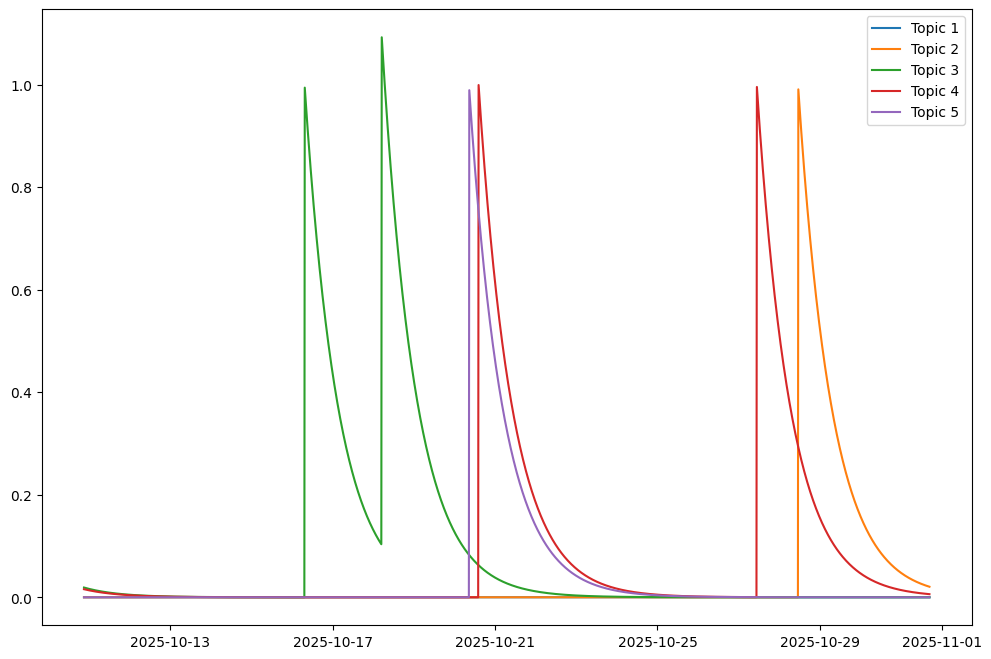

In [21]:
# Quickly graph the weighted counts for the first 2 topics over the past 500 hours to ensure smooth decay

last_500_idx = td_topics_df.index[-2000:] if len(td_topics_df) >= 500 else td_topics_df.index

plt.figure(figsize=(12, 8))
for i in range(5):
    plt.plot(last_500_idx, td_topics_df.loc[last_500_idx, td_topics_df.columns[i]], label=f'Topic {i+1}')
plt.legend()
plt.show()

## Time-Decayed Aggregation for Embeddings
We'll create a new Dataframe called `td_embeddings_df` which will be used as features for the models. 

Similar to what we did in the last section, we want to compute the time-decayed weighted average embedding for every hour. We'll use the same parameter values for `lookback_window` = 336h and `lambda` = 0.05 for the function:

$$weight = e^{- \lambda * HoursSincePublication}$$

One minor difference though, is that once these time-decayed weighted average embeddings have been calculated for every hour, we'll use UMAP to reduce the dimensionality of the embeddings to 20. We'll keep this modular as a function in case we want to disable it and use the full embeddings as features. For now we'll reduce dimensionality and put those into `td_embeddings_df`.

In [24]:
def compute_time_decayed_embeddings(news_df, master_df, lookback_window=336, decay_lambda=0.05, reduce_dim=True, n_components=20):
    """
    Compute time-decayed weighted average embeddings.
    
    For each timestamp in master_df, compute the weighted average embedding of articles
    published within the lookback_window, using exponential time decay.
    
    Weight formula: weight = e^(-lambda * hours_since_publication)
    
    Parameters:
        news_df: DataFrame with columns ['publishedAt', 'embedding']
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        reduce_dim: Whether to reduce dimensionality using UMAP (default: True)
        n_components: Number of dimensions for reduction (default: 20)
    
    Returns:
        pd.DataFrame: DataFrame with datetime index and columns for reduced embedding dimensions
    """
    
    # Convert publishedAt to datetime if needed and handle timezone
    td_embedding_news_df = news_df.copy()
    # Handle both publishedAt and publishedAt column names
    if 'publishedAt' in td_embedding_news_df.columns:
        td_embedding_news_df['publishedAt'] = pd.to_datetime(td_embedding_news_df['publishedAt'])
    elif 'publishedAt' in td_embedding_news_df.columns:
        td_embedding_news_df['publishedAt'] = pd.to_datetime(td_embedding_news_df['publishedAt'])
    else:
        raise ValueError("news_df must contain either 'publishedAt' or 'publishedAt' column")
    
    # Convert timezone-aware datetime to naive datetime (remove timezone info)
    if td_embedding_news_df['publishedAt'].dt.tz is not None:
        td_embedding_news_df['publishedAt'] = td_embedding_news_df['publishedAt'].dt.tz_localize(None)
    
    # Create output DataFrame with same index as master_df
    # First, collect all weighted average embeddings
    weighted_embeddings_list = []
    timestamps_list = []
    
    print(f"Computing time-decayed weighted average embeddings for {len(master_df)} timestamps")
    print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
    
    # Use tqdm progress bar for outer timestamp loop
    for timestamp in tqdm(master_df.index, desc="Processing timestamps", position=0, leave=True):
        # Find all articles published within the lookback window
        cutoff_time = timestamp - timedelta(hours=lookback_window)
        mask = (td_embedding_news_df['publishedAt'] >= cutoff_time) & \
               (td_embedding_news_df['publishedAt'] <= timestamp) & \
               (td_embedding_news_df['embedding'].notna())
        recent_articles = td_embedding_news_df[mask].copy()
        
        if len(recent_articles) == 0:
            # If no articles, create zero embedding (will determine dimension from first non-zero case)
            weighted_embeddings_list.append(None)
        else:
            # Get embedding dimension from first article
            first_embedding = recent_articles.iloc[0]['embedding']
            if isinstance(first_embedding, (list, np.ndarray)):
                embedding_dim = len(first_embedding)
            else:
                embedding_dim = first_embedding.shape[0] if hasattr(first_embedding, 'shape') else None
            
            # Initialize weighted sum and total weight
            weighted_sum = np.zeros(embedding_dim)
            total_weight = 0.0

            # Use tqdm progress bar for recent_articles if you want (optional, e.g. for large inner loops)
            # for idx, row in tqdm(recent_articles.iterrows(), total=recent_articles.shape[0], desc="Recent articles", leave=False):
            for idx, row in recent_articles.iterrows():
                embedding = row['embedding']
                
                # Convert to numpy array if needed
                if isinstance(embedding, list):
                    embedding = np.array(embedding)
                elif not isinstance(embedding, np.ndarray):
                    continue
                
                # Calculate hours since publication
                hours_since = (timestamp - row['publishedAt']).total_seconds() / 3600
                
                # Calculate weight using exponential decay
                weight = np.exp(-decay_lambda * hours_since)
                
                # Add weighted embedding to sum
                weighted_sum += weight * embedding
                total_weight += weight
            
            # Compute weighted average
            if total_weight > 0:
                weighted_avg_embedding = weighted_sum / total_weight
            else:
                weighted_avg_embedding = np.zeros(embedding_dim)
            
            weighted_embeddings_list.append(weighted_avg_embedding)
        
        timestamps_list.append(timestamp)
    
    # Convert list to numpy array, handling None values
    # First, find a non-None embedding to get dimension
    embedding_dim = None
    for emb in weighted_embeddings_list:
        if emb is not None:
            embedding_dim = len(emb)
            break
    
    if embedding_dim is None:
        raise ValueError("No embeddings found. Check that news_df has valid embeddings.")
    
    # Replace None values with zero embeddings
    weighted_embeddings_array = np.array([
        emb if emb is not None else np.zeros(embedding_dim) 
        for emb in weighted_embeddings_list
    ])
    
    print(f"\nCompleted time-decayed aggregation")
    print(f"Embedding shape before reduction: {weighted_embeddings_array.shape}")
    
    # Apply dimensionality reduction if requested
    if reduce_dim:
        print(f"Applying UMAP to reduce to {n_components} dimensions...")
        # Add progress bar to UMAP fitting
        # Since UMAP's fit_transform can be long, wrap it with tqdm for progress feedback
        # But UMAP itself does not accept tqdm, so print and use UMAP's verbose if needed
        reducer = umap.UMAP(n_components=n_components, random_state=42, n_jobs=-1, verbose=True)
        reduced_embeddings = reducer.fit_transform(weighted_embeddings_array) 
        # Create DataFrame with reduced embeddings
        td_embeddings_df = pd.DataFrame(
            reduced_embeddings,
            index=master_df.index,
            columns=[f'embedding_dim_{i}' for i in range(n_components)]
        )
    else:
        # Create DataFrame with full embeddings
        td_embeddings_df = pd.DataFrame(
            weighted_embeddings_array,
            index=master_df.index,
            columns=[f'embedding_dim_{i}' for i in range(embedding_dim)]
        )
    
    print(f"Output shape: {td_embeddings_df.shape}")
    print(f"\nSample of reduced embeddings:")
    print(td_embeddings_df.head(10))
    
    return td_embeddings_df

# Compute time-decayed weighted average embeddings
td_embeddings_df = compute_time_decayed_embeddings(
    news_df, master_df, lookback_window=336, decay_lambda=0.05, reduce_dim=True, n_components=20
)

Computing time-decayed weighted average embeddings for 45867 timestamps
Lookback window: 336h, decay lambda: 0.05


Processing timestamps: 100%|██████████| 45867/45867 [00:15<00:00, 2894.19it/s]
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Completed time-decayed aggregation
Embedding shape before reduction: (45867, 384)
Applying UMAP to reduce to 20 dimensions...
UMAP(n_components=20, n_jobs=1, random_state=42, verbose=True)
Sat Nov  1 14:09:17 2025 Construct fuzzy simplicial set
Sat Nov  1 14:09:17 2025 Finding Nearest Neighbors
Sat Nov  1 14:09:17 2025 Building RP forest with 16 trees
Sat Nov  1 14:09:20 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Sat Nov  1 14:09:26 2025 Finished Nearest Neighbor Search
Sat Nov  1 14:09:27 2025 Construct embedding


Epochs completed:   0%|            1/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [00:52]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:58]

Sat Nov  1 14:10:35 2025 Finished embedding
Output shape: (45867, 20)

Sample of reduced embeddings:
                     embedding_dim_0  embedding_dim_1  embedding_dim_2  \
2020-11-07 23:00:00         7.928027         3.270565         0.389404   
2020-11-08 00:00:00         7.923666         3.266219         0.393774   
2020-11-08 01:00:00         7.927483         3.270034         0.389964   
2020-11-08 02:00:00         7.928234         3.270773         0.389194   
2020-11-08 03:00:00         7.929427         3.271975         0.388011   
2020-11-08 04:00:00         7.927819         3.270373         0.389621   
2020-11-08 05:00:00         7.927992         3.270546         0.389451   
2020-11-08 06:00:00         7.925367         3.267928         0.392074   
2020-11-08 07:00:00         7.920967         3.263513         0.396462   
2020-11-08 08:00:00         7.925322         3.267887         0.392118   

                     embedding_dim_3  embedding_dim_4  embedding_dim_5  \
2020-11-07

In [25]:
print(td_embeddings_df.shape)
td_embeddings_df.head(5)

(45867, 20)


,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
2020-11-07 23:00:00,7.928027,3.270565,0.389404,8.177806,2.174207,8.116295,0.536696,5.859536,1.765421,-2.117049,3.634703,2.743660,0.527008,1.927201,0.952547,-0.780177,2.189641,1.564565,7.005231,1.402596
2020-11-08 00:00:00,7.923666,3.266219,0.393774,8.182037,2.169951,8.120525,0.541079,5.855196,1.769781,-2.112669,3.638998,2.739417,0.522748,1.922941,0.948325,-0.784358,2.193987,1.560293,7.009434,1.406959
2020-11-08 01:00:00,7.927483,3.270034,0.389964,8.178222,2.173770,8.116705,0.537267,5.859012,1.765967,-2.115907,3.635180,2.743242,0.526569,1.926760,0.952148,-0.780540,2.190179,1.564105,7.005614,1.403142
2020-11-08 02:00:00,7.928234,3.270773,0.389194,8.177609,2.174407,8.116096,0.536488,5.859742,1.765215,-2.117384,3.634503,2.743861,0.527207,1.927405,0.952747,-0.779979,2.189438,1.564767,7.005034,1.402391
2020-11-08 03:00:00,7.929427,3.271975,0.388011,8.176327,2.175667,8.114820,0.535310,5.860950,1.764022,-2.117850,3.633265,2.745131,0.528471,1.928661,0.954030,-0.778676,2.188234,1.566012,7.003739,1.401195


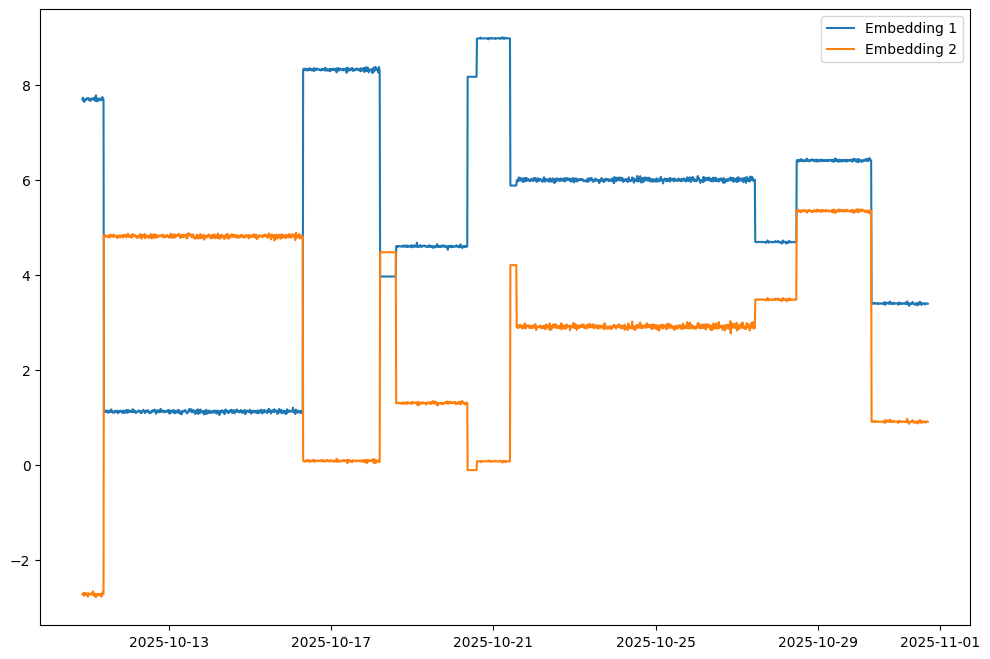

In [29]:
# Only plot the last 2000 hours for the first 5 embeddings to ensure smooth decay

plt.figure(figsize=(12, 8))
plot_df = td_embeddings_df.tail(2000)
for i in range(2):
    plt.plot(plot_df.index, plot_df[plot_df.columns[i]], label=f'Embedding {i+1}')
plt.legend()
plt.show()

now we merge all the features together

In [ ]:
merged_df = master_df.join([td_topics_df, td_embeddings_df], how='left')
print(merged_df.shape)
merged_df.head(5)

---
# Model Training and Validation
In this section we'll create and train 4 models:
- Two XGBoost models, one basline and one advanced
- Two Linear Regressions, one baseline and one advanced

The baseline models, means we'll only use the lagged and temporal features and in the advanced model we'll also use the time decayed topics and embeddings.

First the `master_df` will be split into a training and test set (80/20 split). The training set will further be split into a training and validation set (60/40) as we will fit these models using an expanding window methodology, meaning we'll retrain every N hours (24 here) as the window expands.

In [ ]:
# Prepare data for training
model_df = merged_df.dropna(subset=['target']).copy()

# Define baseline features (lagged + temporal features)
baseline_features = [
    'price_lag_24', 'price_lag_168', 
    'total_power_lag_24', 'total_power_lag_168',
    'hour', 'month', 'day_of_week', 'day_of_year', 'week_of_year'
]

# Get topic columns (all columns that are not baseline features, target, price, or total_power)
topic_cols = [col for col in model_df.columns 
              if col not in baseline_features and 
              col not in ['target', 'price', 'total_power'] and 
              not col.startswith('embedding_dim_')]

# Get embedding columns
embedding_cols = [col for col in model_df.columns if col.startswith('embedding_dim_')]

# Define advanced features (baseline + topics + embeddings)
advanced_features = baseline_features + topic_cols + embedding_cols

print(f"Data shape: {model_df.shape}")
print(f"Baseline features: {len(baseline_features)}")
print(f"Topic features: {len(topic_cols)}")
print(f"Embedding features: {len(embedding_cols)}")
print(f"Advanced features (total): {len(advanced_features)}")
print(f"\nBaseline features: {baseline_features}")
print(f"\nTopic features: {topic_cols[:5]}..." if len(topic_cols) > 5 else f"\nTopic features: {topic_cols}")
print(f"\nEmbedding features: {embedding_cols[:5]}..." if len(embedding_cols) > 5 else f"\nEmbedding features: {embedding_cols}")


In [ ]:
# Split data into train (80%) and test (20%)
train_size = int(len(model_df) * 0.8)
train_df = model_df.iloc[:train_size].copy()
test_df = model_df.iloc[train_size:].copy()

print(f"Train set: {len(train_df)} samples from {train_df.index[0]} to {train_df.index[-1]}")
print(f"Test set: {len(test_df)} samples from {test_df.index[0]} to {test_df.index[-1]}")

# Split train into train (60%) and validation (40%)
train_len = int(len(train_df) * 0.6)
train_set = train_df.iloc[:train_len].copy()
val_set = train_df.iloc[train_len:].copy()

print(f"\nTrain subset: {len(train_set)} samples")
print(f"Validation subset: {len(val_set)} samples")

# Expanding window training with retraining every 24 hours
retrain_frequency = 24
last_retrain_idx = 0

# Prepare feature standardization for news features (topics + embeddings)
news_features = topic_cols + embedding_cols
scaler_news = None

# Initialize storage for trained models and predictions
models = {
    'lr_baseline': None,
    'lr_advanced': None,
    'xgb_baseline': None,
    'xgb_advanced': None
}

print(f"\nStarting expanding window training...")
print(f"Retraining frequency: every {retrain_frequency} hours")
print(f"Validation samples to process: {len(val_set)}")


In [ ]:
# Expanding window training loop with progress bar for training
num_retrains = 0
train_pbar = tqdm(total=(len(val_set) // retrain_frequency) + 1, desc="Model Retrain", position=1, leave=True)

for i in tqdm(range(len(val_set)), desc="Expanding window training", position=0):
    # Current training window: all data from start to current validation point
    train_end_idx = len(train_set) + i
    current_train_data = train_df.iloc[:train_end_idx]
    
    # Check if we need to retrain
    if i == 0 or (i - last_retrain_idx) >= retrain_frequency:
        # Fit scaler on news features for current training data
        scaler_news = StandardScaler()
        current_news_features = current_train_data[news_features].fillna(0)
        scaler_news.fit(current_news_features)
        
        # Prepare baseline features
        X_train_baseline = current_train_data[baseline_features].fillna(0)
        
        # Prepare advanced features with standardized news features
        X_train_news_scaled = scaler_news.transform(current_train_data[news_features].fillna(0))
        X_train_advanced = np.column_stack([
            current_train_data[baseline_features].fillna(0),
            X_train_news_scaled
        ])
        
        y_train = current_train_data['target']
        
        # Progress for training step of each model
        model_train_pbar = tqdm(total=4, desc=f"Training models (val i={i})", position=2, leave=False)
        # Train baseline models
        models['lr_baseline'] = LinearRegression()
        models['lr_baseline'].fit(X_train_baseline, y_train)
        model_train_pbar.update(1)
        
        models['xgb_baseline'] = XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        models['xgb_baseline'].fit(X_train_baseline, y_train)
        model_train_pbar.update(1)
        
        # Train advanced models
        models['lr_advanced'] = LinearRegression()
        models['lr_advanced'].fit(X_train_advanced, y_train)
        model_train_pbar.update(1)
        
        models['xgb_advanced'] = XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        models['xgb_advanced'].fit(X_train_advanced, y_train)
        model_train_pbar.update(1)
        model_train_pbar.close()
        
        last_retrain_idx = i
        num_retrains += 1
        train_pbar.update(1)

train_pbar.close()

print(f"\nTraining completed!")
print(f"Models trained: {num_retrains} times")
print(f"\nFinal models are stored in the 'models' dictionary:")
for model_name in models.keys():
    print(f"  - {model_name}: {'✓' if models[model_name] is not None else '✗'}")
